In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
a = 5
b = 0.2
p_h, p_l = 12, 10
s = 20
T = 400
lam = 0.2
price_dict = {0:p_h, 1: p_l}

# Capacity as Public Information

In [3]:
def initial (s, T, a, b, p_h, p_l):
    if p_h <= p_l:
        raise ValueError("Incorrect Parameters")
    if a - b*p_h < 0:
        raise ValueError("Incorrect Parameters")
    l, h = np.exp(a-b*p_l), np.exp(a-b*p_h)
    ll, lh = l / (1+2*l), l / (1+l+h)
    hl, hh = h / (1+l+h), h / (1+2*h)
    V = np.zeros((s+1, s+1, T+1))
    P = -np.ones((s+1, s+1, T+1, 2))
    q_l, q_h = l / (1+l), h / (1+h)
    for t in range(1, T+1):
        for si in range(1, s+1):
            reward_h = lam*q_h*(p_h+V[si-1][0][t-1]) + (1-lam*q_h)*V[si][0][t-1]
            reward_l = lam*q_l*(p_l+V[si-1][0][t-1]) + (1-lam*q_l)*V[si][0][t-1]
            V[si][0][t] = max(reward_h, reward_l)
    return [[hh, hl], [lh, ll]], V, P

prob_matrix, V, P = initial(s, T, a, b, p_h, p_l)

In [4]:
def payoff(x, y, si, s_i, t):
    q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
    p_x, p_y = price_dict[x], price_dict[y]
    ri = q_xy*(p_x+V[si-1][s_i][t-1]) + q_yx*V[si][s_i-1][t-1] + (1-q_xy-q_yx)*V[si][s_i][t-1]
    r_i = q_xy*V[s_i][si-1][t-1] + q_yx*(p_y+V[s_i-1][si][t-1]) + (1-q_xy-q_yx)*V[s_i][si][t-1]
    return ri, r_i

In [5]:
hh, hl, lh, ll = 0, 0, 0, 0
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
        for s_i in range(1, s+1):
            hhi, hh_i = payoff(0, 0, si, s_i, t)
            hli, hl_i = payoff(0, 1, si, s_i, t)
            lhi, lh_i = payoff(1, 0, si, s_i, t)
            lli, ll_i = payoff(1, 1, si, s_i, t)
            if hhi >= lhi and hh_i >= hl_i:
                p, q = 1, 1
                hh += 1
            elif hli >= lli and hl_i >= hh_i:
                p, q = 1, 0
                hl += 1
            elif lhi >= hhi and lh_i >= ll_i:
                p, q = 0, 1
                lh += 1
            elif lli >= hli and ll_i >= lh_i:
                p, q = 0, 0
                ll += 1
            else:
                p = (ll_i-lh_i) / (hh_i - hl_i + ll_i - lh_i)
                q = (lli-hli) / (hhi - lhi + lli - hli)
            P[si,s_i,t,0], P[si,s_i,t,1] = p, q
            V[si][s_i][t] = (1-lam) * V[si][s_i][t-1]
            V[si][s_i][t] += lam * p * q * hhi
            V[si][s_i][t] += lam * (1-p) * q * lhi
            V[si][s_i][t] += lam * p * (1-q) * hli
            V[si][s_i][t] += lam * (1-p) * (1-q) * lli
np.save('V_0915.npy', V)

100%|██████████| 400/400 [00:01<00:00, 272.96it/s]


In [6]:
mask =  (P != 0) & (P != -1) & (P != 1)
count = np.count_nonzero(mask)
print(count, mask.size)
print(hh, hl, lh, ll)

0 353682
140783 1141 1141 16935


# Capacity as Private Information (Old Approach 240915)

In [7]:
VV = np.zeros((s+1, s+1, s+1, s+1, T+1))
l, h = np.exp(a-b*p_l), np.exp(a-b*p_h)
q_l, q_h = l / (1+l), h / (1+h)

In [8]:
# initial boudary condition for states when both si_ and s_i_ are zero
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
        for s_i in range(1, s+1):
            reward_h = lam*q_h*(p_h+V[si-1][0][t-1]) + (1-lam*q_h)*V[si][0][t-1]
            reward_l = lam*q_l*(p_l+V[si-1][0][t-1]) + (1-lam*q_l)*V[si][0][t-1]
            x = 0 if reward_h >= reward_l else 1
            reward_h = lam*q_h*(p_h+V[s_i-1][0][t-1]) + (1-lam*q_h)*V[s_i][0][t-1]
            reward_l = lam*q_l*(p_l+V[s_i-1][0][t-1]) + (1-lam*q_l)*V[s_i][0][t-1]
            y = 0 if reward_h >= reward_l else 1
            q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
            p_x, p_y = price_dict[x], price_dict[y]
            l_xy, l_yx = (lam*q_xy) / (1-lam*q_yx), (lam*q_yx) / (1-lam*q_xy)
            temp = lam * q_xy * (p_x + l_xy*VV[si-1][s_i][0][0][t-1] + (1-l_xy)*VV[si-1][s_i][0][0][t-1])
            temp += lam * q_yx * (p_y + l_yx*VV[si][s_i-1][0][0][t-1] + (1-l_yx)*VV[si][s_i-1][0][0][t-1])
            temp1 = l_xy * l_yx * VV[si][s_i][0][0][t-1] + l_xy * (1-l_yx) * VV[si][s_i][0][0][t-1] + (1-l_xy) * l_yx * VV[si][s_i][0][0][t-1] + (1-l_yx) * (1-l_xy) * VV[si][s_i][0][0][t-1]
            temp1 *= (1 - lam*q_xy - lam*q_yx)
            VV[si][s_i][0][0][t] += temp + temp1


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:01<00:00, 326.64it/s]


In [9]:
# initial boudary condition for states when only s_i_ is zero
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
        for s_i in range(1, s+1):
            for si_ in range(1, s+1):
                reward_h = lam*q_h*(p_h+V[si-1][0][t-1]) + (1-lam*q_h)*V[si][0][t-1]
                reward_l = lam*q_l*(p_l+V[si-1][0][t-1]) + (1-lam*q_l)*V[si][0][t-1]
                x = 0 if reward_h >= reward_l else 1
                y = int(1-P[s_i][si_][t][0])
                q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
                p_x, p_y = price_dict[x], price_dict[y]
                l_xy, l_yx = (lam*q_xy) / (1-lam*q_yx), (lam*q_yx) / (1-lam*q_xy)
                temp = lam * q_xy * (p_x + l_xy*VV[si-1][s_i][si_-1][0][t-1] + (1-l_xy)*VV[si-1][s_i][si_][0][t-1])
                temp += lam * q_yx * (p_y + l_yx*VV[si][s_i-1][si_][0][t-1] + (1-l_yx)*VV[si][s_i-1][si_][0][t-1])
                temp1 = l_xy * l_yx * VV[si][s_i][si_-1][0][t-1] + l_xy * (1-l_yx) * VV[si][s_i][si_-1][0][t-1] + (1-l_xy) * l_yx * VV[si][s_i][si_][0][t-1] + (1-l_yx) * (1-l_xy) * VV[si][s_i][si_][0][t-1]
                temp1 *= (1 - lam*q_xy - lam*q_yx)
                VV[si][s_i][si_][0][t] += temp + temp1

100%|██████████| 400/400 [00:21<00:00, 18.36it/s]


In [10]:
# initial boudary condition for states when si_ is zero
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
        for s_i in range(1, s+1):
            for s_i_ in range(1, s+1):
                reward_h = lam*q_h*(p_h+V[s_i-1][0][t-1]) + (1-lam*q_h)*V[s_i][0][t-1]
                reward_l = lam*q_l*(p_l+V[s_i-1][0][t-1]) + (1-lam*q_l)*V[s_i][0][t-1]
                y = 0 if reward_h >= reward_l else 1
                x = int(1-P[si][s_i_][t][0])
                q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
                p_x, p_y = price_dict[x], price_dict[y]
                l_xy, l_yx = (lam*q_xy) / (1-lam*q_yx), (lam*q_yx) / (1-lam*q_xy)
                temp = lam * q_xy * (p_x + l_xy*VV[si-1][s_i][0][s_i_][t-1] + (1-l_xy)*VV[si-1][s_i][0][s_i_][t-1])
                temp += lam * q_yx * (p_y + l_yx*VV[si][s_i-1][0][s_i_-1][t-1] + (1-l_yx)*VV[si][s_i-1][0][s_i_][t-1])
                temp1 = l_xy * l_yx * VV[si][s_i][0][s_i_-1][t-1] + l_xy * (1-l_yx) * VV[si][s_i][0][s_i_][t-1] + (1-l_xy) * l_yx * VV[si][s_i][0][s_i_-1][t-1] + (1-l_yx) * (1-l_xy) * VV[si][s_i][0][s_i_][t-1]
                temp1 *= (1 - lam*q_xy - lam*q_yx)
                VV[si][s_i][0][s_i_][t] += temp + temp1

100%|██████████| 400/400 [00:21<00:00, 18.90it/s]


In [11]:
# initial boudary condition for states when s_i is zero
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
            for si_ in range(s+1):
                for s_i_ in range(s+1):
                    VV[si][0][si_][s_i_][t] = V[si][0][t]

# initial boudary condition for states when si is zero            
for t in tqdm(range(1, T+1)):
    for s_i in range(1, s+1):
            for si_ in range(s+1):
                for s_i_ in range(s+1):
                    VV[0][s_i][si_][s_i_][t] = V[s_i][0][t]

100%|██████████| 400/400 [00:01<00:00, 234.31it/s]


In [12]:
def Bellman_update(si, s_i, si_, s_i_, t, x=None, y=None):
    if x is None:
        x = 1-P[si][s_i_][t][0]
    if y is None:
        y = 1-P[s_i][si_][t][0]
    q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
    p_x, p_y = price_dict[x], price_dict[y]
    l_xy, l_yx = (lam*q_xy) / (1-lam*q_yx), (lam*q_yx) / (1-lam*q_xy)
    temp = lam * q_xy * (p_x + l_xy*VV[si-1][s_i][si_-1][s_i_][t-1] + (1-l_xy)*VV[si-1][s_i][si_][s_i_][t-1])
    temp += lam * q_yx * (p_y + l_yx*VV[si][s_i-1][si_][s_i_-1][t-1] + (1-l_yx)*VV[si][s_i-1][si_][s_i_][t-1])
    temp1 = l_xy * l_yx * VV[si][s_i][si_-1][s_i_-1][t-1] + l_xy * (1-l_yx) * VV[si][s_i][si_-1][s_i_][t-1] + (1-l_xy) * l_yx * VV[si][s_i][si_][s_i_-1][t-1] + (1-l_yx) * (1-l_xy) * VV[si][s_i][si_][s_i_][t-1]
    temp1 *= (1 - lam*q_xy - lam*q_yx)
    VV[si][s_i][si_][s_i_][t] += temp + temp1

In [13]:
for t in tqdm(range(1, T+1)):
    for si in range(1, s+1):
        for s_i in range(1, s+1):
            for si_ in range(1, s+1):
                for s_i_ in range(1, s+1):
                    x = int(1-P[si][s_i_][t][0])
                    y = int(1-P[s_i][si_][t][0])
                    q_xy, q_yx = prob_matrix[x][y], prob_matrix[y][x]
                    p_x, p_y = price_dict[x], price_dict[y]
                    l_xy, l_yx = (lam*q_xy) / (1-lam*q_yx), (lam*q_yx) / (1-lam*q_xy)
                    temp = lam * q_xy * (p_x + l_xy*VV[si-1][s_i][si_-1][s_i_][t-1] + (1-l_xy)*VV[si-1][s_i][si_][s_i_][t-1])
                    temp += lam * q_yx * (p_y + l_yx*VV[si][s_i-1][si_][s_i_-1][t-1] + (1-l_yx)*VV[si][s_i-1][si_][s_i_][t-1])
                    temp1 = l_xy * l_yx * VV[si][s_i][si_-1][s_i_-1][t-1] + l_xy * (1-l_yx) * VV[si][s_i][si_-1][s_i_][t-1] + (1-l_xy) * l_yx * VV[si][s_i][si_][s_i_-1][t-1] + (1-l_yx) * (1-l_xy) * VV[si][s_i][si_][s_i_][t-1]
                    temp1 *= (1 - lam*q_xy - lam*q_yx)
                    VV[si][s_i][si_][s_i_][t] += temp + temp1

100%|██████████| 400/400 [06:06<00:00,  1.09it/s]


In [14]:
np.save('VV_0915.npy', VV)

# Comparison (Symmetric Setting)

C:\Users\TC\AppData\Local\Temp\ipykernel_21216\1909805086.py:6: RuntimeWarning: invalid value encountered in scalar divide
  ratios = [o / t for o, t in zip(opaque, transparent)]


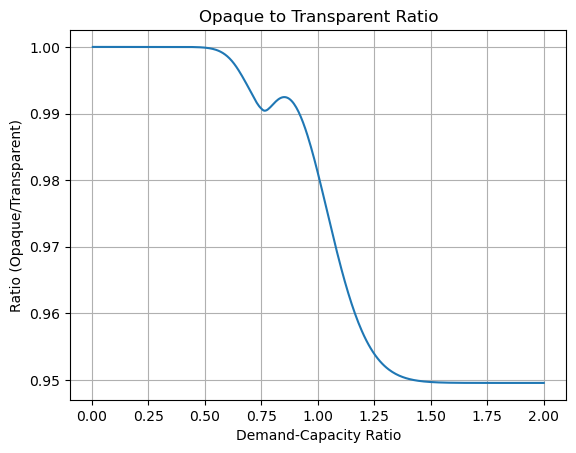

In [15]:
s = 20
opaque, transparent = [], []
for i in range(T+1):
    opaque.append(VV[s][s][s][s][i]/2)
    transparent.append(V[s][s][i])
ratios = [o / t for o, t in zip(opaque, transparent)]

xs = np.arange(T+1)
plt.plot(xs/(10*s), ratios)
plt.title("Opaque to Transparent Ratio")
plt.xlabel("Demand-Capacity Ratio")
plt.ylabel("Ratio (Opaque/Transparent)")
plt.grid(True)
plt.savefig('ratio1.png')


C:\Users\TC\AppData\Local\Temp\ipykernel_21216\2622087023.py:6: RuntimeWarning: invalid value encountered in scalar divide
  ratios = [o / t for o, t in zip(opaque, transparent)]


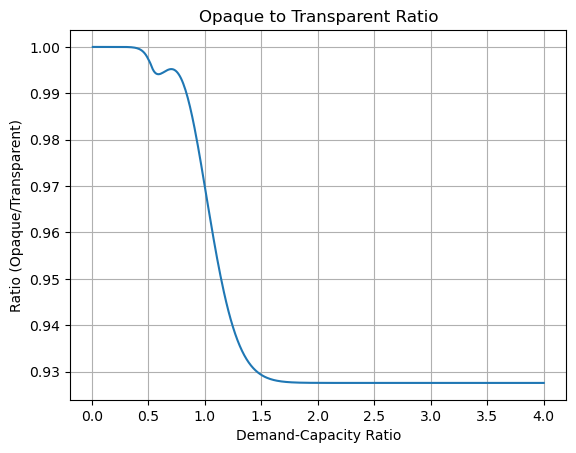

In [16]:
s = 10
opaque, transparent = [], []
for i in range(T+1):
    opaque.append(VV[s][s][s][s][i]/2)
    transparent.append(V[s][s][i])
ratios = [o / t for o, t in zip(opaque, transparent)]

xs = np.arange(T+1)
plt.plot(xs/(10*s), ratios)
plt.title("Opaque to Transparent Ratio")
plt.xlabel("Demand-Capacity Ratio")
plt.ylabel("Ratio (Opaque/Transparent)")
plt.grid(True)
plt.savefig('ratio2.png')

C:\Users\TC\AppData\Local\Temp\ipykernel_21216\2887242967.py:6: RuntimeWarning: invalid value encountered in scalar divide
  ratios = [o / t for o, t in zip(opaque, transparent)]


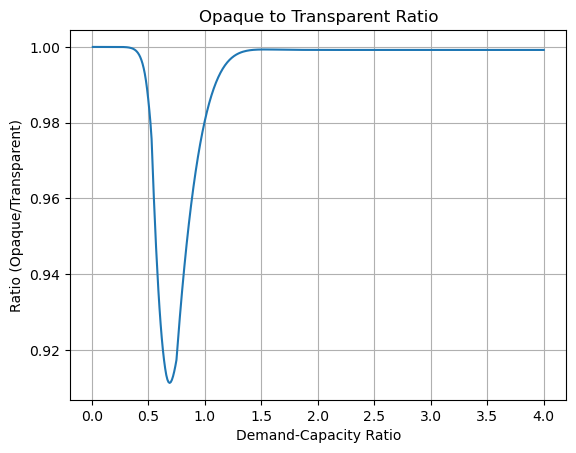

In [17]:
s = 10
opaque, transparent = [], []
for i in range(T+1):
    opaque.append(VV[s][s][20][20][i]/2)
    transparent.append(V[s][s][i])
ratios = [o / t for o, t in zip(opaque, transparent)]

xs = np.arange(T+1)
plt.plot(xs/(10*s), ratios)
plt.title("Opaque to Transparent Ratio")
plt.xlabel("Demand-Capacity Ratio")
plt.ylabel("Ratio (Opaque/Transparent)")
plt.grid(True)
plt.savefig('ratio3.png')

C:\Users\TC\AppData\Local\Temp\ipykernel_21216\3251616531.py:6: RuntimeWarning: invalid value encountered in scalar divide
  ratios = [o / t for o, t in zip(opaque, transparent)]


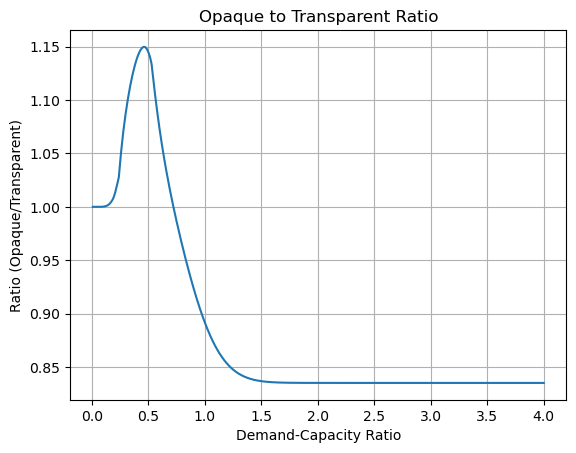

In [18]:
s = 10
opaque, transparent = [], []
for i in range(T+1):
    opaque.append(VV[s][s][5][5][i]/2)
    transparent.append(V[s][s][i])
ratios = [o / t for o, t in zip(opaque, transparent)]

xs = np.arange(T+1)
plt.plot(xs/(10*s), ratios)
plt.title("Opaque to Transparent Ratio")
plt.xlabel("Demand-Capacity Ratio")
plt.ylabel("Ratio (Opaque/Transparent)")
plt.grid(True)
plt.savefig('ratio4.png')

C:\Users\TC\AppData\Local\Temp\ipykernel_21216\82139387.py:6: RuntimeWarning: invalid value encountered in scalar divide
  ratios = [o / t for o, t in zip(opaque, transparent)]


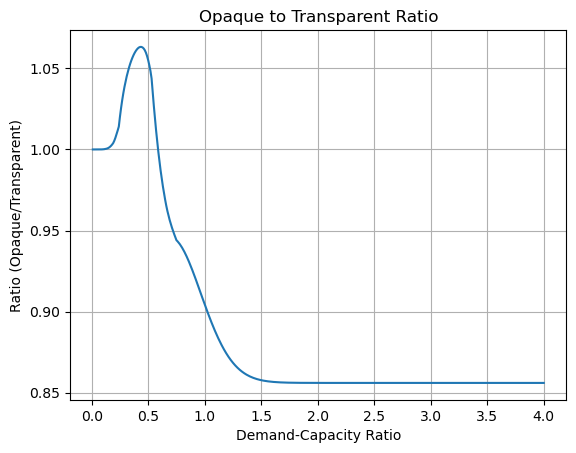

In [19]:
s = 10
opaque, transparent = [], []
for i in range(T+1):
    opaque.append(VV[s][s][5][20][i]/2)
    transparent.append(V[s][s][i])
ratios = [o / t for o, t in zip(opaque, transparent)]

xs = np.arange(T+1)
plt.plot(xs/(10*s), ratios)
plt.title("Opaque to Transparent Ratio")
plt.xlabel("Demand-Capacity Ratio")
plt.ylabel("Ratio (Opaque/Transparent)")
plt.grid(True)
plt.savefig('ratio5.png')